In [1]:
import pandas as pd

df = pd.read_csv('/content/predictive_maintenance.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [3]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Duplicate rows: 0


In [4]:
print(df['Target'].value_counts())

print("\nTarget percentage:")
print(df['Target'].value_counts(normalize=True) * 100)

Target
0    9661
1     339
Name: count, dtype: int64

Target percentage:
Target
0    96.61
1     3.39
Name: proportion, dtype: float64


In [5]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [6]:
df.groupby('Target')[[
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Target,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [7]:
df['Failure Type'].value_counts()

,count
Failure Type,
No Failure,9652
Heat Dissipation Failure,112
Power Failure,95
Overstrain Failure,78
Tool Wear Failure,45
Random Failures,18


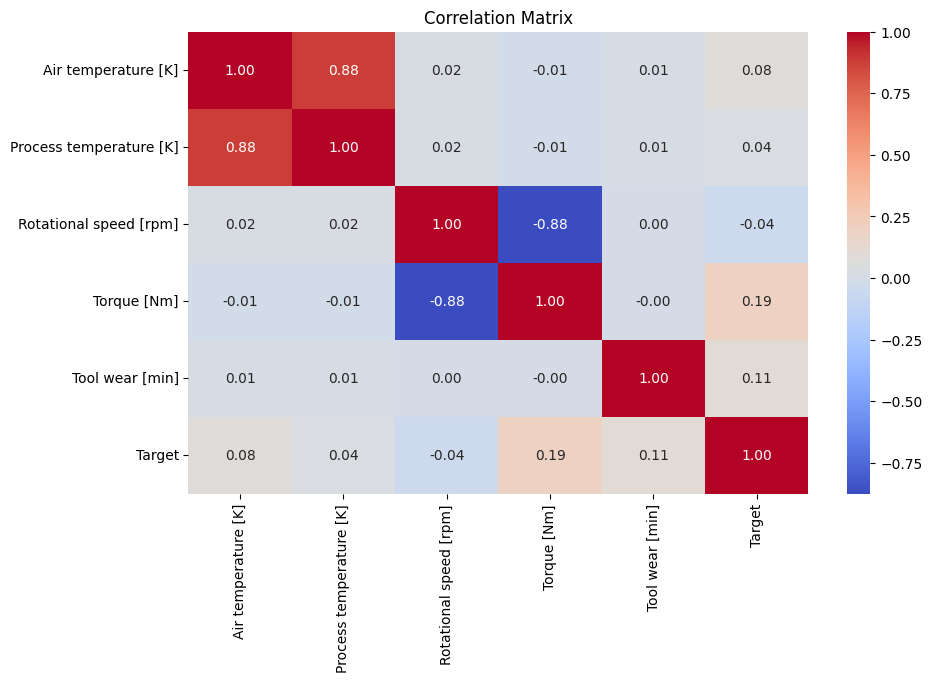

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]',
    'Target'
]

plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [9]:
X = df.drop(columns=['Target', 'UDI', 'Product ID', 'Failure Type'])
y = df['Target']

X = pd.get_dummies(X, columns=['Type'], drop_first=True)

print("Features:")
print(X.columns)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
Index(['Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L',
       'Type_M'],
      dtype='object')

Feature shape: (10000, 7)
Target shape: (10000,)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 7)
Testing data: (2000, 7)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [12]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8275

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.83      0.90      1932
           1       0.14      0.82      0.25        68

    accuracy                           0.83      2000
   macro avg       0.57      0.83      0.57      2000
weighted avg       0.96      0.83      0.88      2000


Confusion Matrix:
[[1599  333]
 [  12   56]]


In [13]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 0.9295

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1932
           1       0.31      0.88      0.46        68

    accuracy                           0.93      2000
   macro avg       0.65      0.91      0.71      2000
weighted avg       0.97      0.93      0.95      2000


Confusion Matrix:
[[1799  133]
 [   8   60]]


In [14]:
from sklearn.metrics import roc_auc_score

dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("ROC-AUC Score:", roc_auc_score(y_test, dt_prob))

ROC-AUC Score: 0.9079474180976739


In [15]:
import joblib

joblib.dump(dt_model, 'machine_failure_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [16]:
joblib.dump(X.columns.tolist(), 'model_features.pkl')

print("Model and feature structure saved successfully!")

Model and feature structure saved successfully!


In [ ]:
from pathlib import Path
import joblib
import pandas as pd
import sklearn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

project_dir = Path.cwd().resolve()
while not (project_dir / "app.py").is_file():
    parent_dir = project_dir.parent
    if parent_dir == project_dir:
        raise FileNotFoundError("Run this cell from the project folder or one of its subfolders.")
    project_dir = parent_dir
dataset_path = project_dir / "data" / "ai4i2020.csv"
model_path = project_dir / "models" / "machine_failure_model.pkl"

raw_data = pd.read_csv(dataset_path)
target_column = "Machine failure" if "Machine failure" in raw_data.columns else "Target"
input_columns = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type",
]
missing_columns = [column for column in [*input_columns, target_column] if column not in raw_data.columns]
if missing_columns:
    raise ValueError(f"Dataset is missing required columns: {missing_columns}")

training_data = raw_data[[*input_columns, target_column]].rename(columns={target_column: "Target"})
X = pd.get_dummies(training_data[input_columns], columns=["Type"], drop_first=True)
feature_order = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
    "Type_L",
    "Type_M",
]
if set(X.columns) != set(feature_order):
    raise ValueError(f"Unexpected model feature schema: {X.columns.tolist()}")
X = X[feature_order]
y = training_data["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42,
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

model_path.parent.mkdir(parents=True, exist_ok=True)
joblib.dump({"model": dt_model, "features": feature_order}, model_path)

print(f"Dataset: {len(raw_data):,} rows from {dataset_path}")
print(f"Training rows: {len(X_train):,}; test rows: {len(X_test):,}")
print(f"Features: {feature_order}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Decision Tree accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Decision Tree ROC-AUC: {roc_auc_score(y_test, dt_prob):.4f}")
print("Classification report:")
print(classification_report(y_test, dt_pred, zero_division=0))
print("Confusion matrix:")
print(confusion_matrix(y_test, dt_pred))
print(f"Model artifact saved to: {model_path}")